# Limpieza y Transformación de los datos
Fecha: 29 de mayo del 2026

Autor: Maria Reina Zarate Nava


In [70]:
# Importamos librerias principales
import pandas as pd 
import numpy as np #Trabajar datos y series

In [71]:
# Importamos librerias para graficas
import matplotlib.pyplot as plt

In [72]:
import seaborn as sns

In [73]:
#Cargamos el dataset crudo/sucio
dfCrudo = pd.read_csv("../Data/dataset_sucio_practica.csv")

In [74]:
dfCrudo

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
...,...,...,...,...,...,...,...,...
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No


In [75]:
#Generar una copia del dataframe
dfCrudoCopia = dfCrudo.copy()

In [76]:
#Vamos a mostrar los valores nulos
dfCrudoCopia.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    str    
 2   edad            110 non-null    float64
 3   correo          125 non-null    str    
 4   pais            82 non-null     str    
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    str    
 7   activo          90 non-null     str    
dtypes: float64(2), int64(1), str(5)
memory usage: 7.9 KB


In [77]:
dfCrudoCopia.describe()

,id,edad,salario
count,125.000000,110.000000,107.000000
mean,58.200000,43.945455,14093.457944
std,35.906465,47.489803,8825.918852
min,1.000000,-5.000000,-1000.000000
25%,27.000000,22.750000,12000.000000
50%,58.000000,30.000000,15000.000000
75%,89.000000,40.000000,18000.000000
max,120.000000,150.000000,25000.000000


In [78]:
#Mostramos el total de valores nulos
dfCrudoCopia.isnull().sum()

id                 0
nombre             9
edad              15
correo             0
pais              43
salario           18
fecha_registro     0
activo            35
dtype: int64

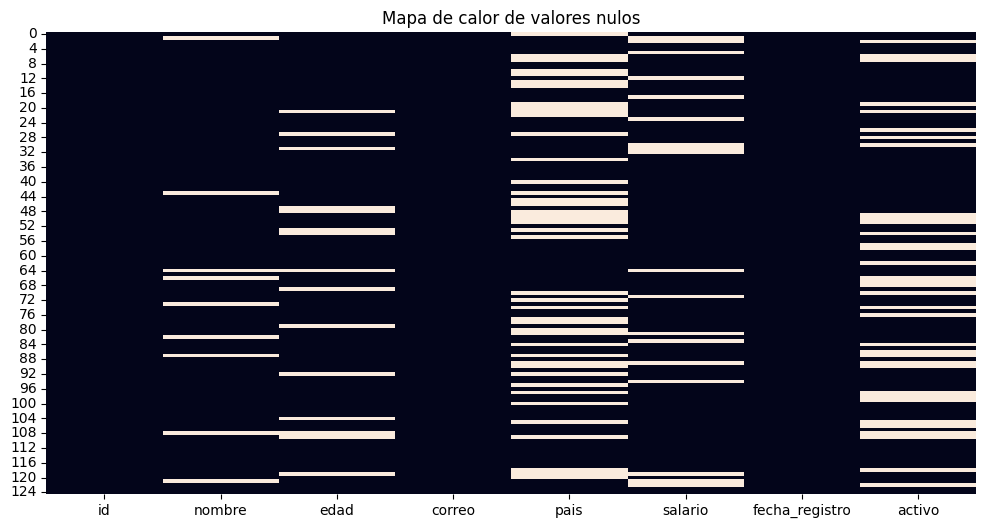

In [79]:
plt.figure(figsize=(12,6))
sns.heatmap(dfCrudoCopia.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos")
plt.show()


# LIMPIEZA DE DATOS
1. Eliminar datos duplicados
2. Imputar valores nulos
3. Corregir outlier (Valores fuera de rango)


In [80]:
# 1. Eliminamos datos duplicados
dfCrudoCopia.duplicated().sum()

np.int64(5)

In [81]:
dfCrudoCopia.drop_duplicates(inplace=True) #Elimina datos duplicados

In [82]:
dfCrudoCopia.duplicated().sum()

np.int64(0)

In [83]:
# 2. Verificamos la existencia de edades fuera de rango
dfCrudoCopia[
    (dfCrudoCopia["edad"]<0 )|(dfCrudoCopia["edad"]>100)
    ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
6,7,Roberto Smith,-5.0,vegasara@yahoo.com,NaN,12000.0,2026-03-31,NaN
7,8,Nicholas Torres,-5.0,arnoldjoe@macias.biz,NaN,12000.0,2026-04-07,NaN
9,10,Angela Richards,-5.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
12,13,Paul Liu,150.0,ilong@gmail.com,España,NaN,2025-11-21,No
16,17,Christopher Klein,-5.0,ericarice@hotmail.com,España,18000.0,2024-09-22,Sí
22,23,Mrs. Diane Carter,150.0,schultzpatrick@mccoy.net,NaN,18000.0,2024-10-31,No
23,24,Vicki Love,-5.0,antonio14@johnson.net,Argentina,NaN,2026-01-24,No
24,25,Matthew Porter,-5.0,hansoncameron@yahoo.com,Argentina,12000.0,2025-11-17,No


In [84]:
#Convertimos las edades invalidas en NaN
dfCrudoCopia.loc[
    (dfCrudoCopia["edad"]<0) | (dfCrudoCopia["edad"]>100),"edad"
    ] = np.nan

In [85]:
dfCrudoCopia[
    (dfCrudoCopia["edad"]<0 )|(dfCrudoCopia["edad"]>100)
    ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [86]:
#Calculamos la mediana del campo edad
mediana_edad = dfCrudoCopia["edad"].median()
mediana_edad

np.float64(30.0)

In [87]:
dfCrudoCopia["edad"]= dfCrudoCopia["edad"].fillna(mediana_edad)

In [88]:
dfCrudoCopia["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [89]:
# Identificar los salarios negativos
dfCrudoCopia[
    (dfCrudoCopia["salario"]<0)
    ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
9,10,Angela Richards,30.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
11,12,Daniel Wright,25.0,melissamaxwell@gmail.com,NaN,-1000.0,2024-12-20,Sí
20,21,Marc Miller DDS,30.0,ccalderon@campbell-carter.com,NaN,-1000.0,2024-06-25,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,-1000.0,2025-05-05,NaN
26,27,Mary Miranda,40.0,brendaglenn@gmail.com,Argentina,-1000.0,2025-06-01,NaN
27,28,John Taylor,30.0,jonesashley@hotmail.com,NaN,-1000.0,2025-08-02,No
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
37,38,Brian Sherman,30.0,brianna61@yahoo.com,Argentina,-1000.0,2024-09-17,Sí
41,42,Patricia Morrison,30.0,uweiss@yahoo.com,Argentina,-1000.0,2026-03-10,No
44,45,John Estrada,35.0,nichole26@hotmail.com,Argentina,-1000.0,2025-12-12,Sí


In [90]:
#Asignarle NaN
dfCrudoCopia.loc[
    (dfCrudoCopia["salario"]<0), "salario"
    ] = np.nan

In [91]:
mediana_salario = dfCrudoCopia["salario"].median()
mediana_salario

np.float64(15000.0)

In [92]:
#Asignamos la mediana del salario a los valores Nan
dfCrudoCopia["salario"] = dfCrudoCopia["salario"].fillna(mediana_salario)

In [93]:
dfCrudoCopia["salario"].describe()

count      120.000000
mean     16741.666667
std       4401.099621
min      12000.000000
25%      15000.000000
50%      15000.000000
75%      18000.000000
max      25000.000000
Name: salario, dtype: float64

In [94]:
dfCrudoCopia.describe()

,id,edad,salario
count,120.000000,120.000000,120.000000
mean,60.500000,30.325000,16741.666667
std,34.785054,4.745918,4401.099621
min,1.000000,22.000000,12000.000000
25%,30.750000,30.000000,15000.000000
50%,60.500000,30.000000,15000.000000
75%,90.250000,31.250000,18000.000000
max,120.000000,40.000000,25000.000000


In [98]:
# Variables de tipo cadena / string / object
# Identificamos aquellos correos que NO contienen arroba
dfCrudoCopia[
    ~dfCrudoCopia["correo"].str.contains("@", na=False)
    ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,correo_invalido,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,correo_invalido,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,15000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,correo_invalido,Argentina,15000.0,2026-03-07,NaN
40,41,Cynthia Arnold,30.0,correo_invalido,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,correo_invalido,España,15000.0,2025-12-01,No
78,79,Charles Page,25.0,correo_invalido,NaN,15000.0,2025-09-01,No
87,88,NaN,22.0,correo_invalido,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,30.0,correo_invalido,Argentina,12000.0,2024-11-16,Sí


In [99]:
correos_invalidos =  ~dfCrudoCopia["correo"].str.contains("@", na=False)
correos_invalidos

0      False
1      False
2      False
3       True
4       True
       ...  
115    False
116    False
117    False
118    False
119    False
Name: correo, Length: 120, dtype: bool

In [100]:
#Los correos invalidos, los asiganmos con NA
dfCrudoCopia.loc[correos_invalidos, "correo"] = pd.NA

In [102]:
#Agregamos una columna, para identificar los correos validos
dfCrudoCopia["correo_valido"] = dfCrudoCopia["correo"].str.contains("@",na=False)

In [103]:
#Mostramos los primeros 5 registros
dfCrudoCopia.head(5)

,id,nombre,edad,correo,pais,salario,fecha_registro,activo,correo_valido
0,1,Julia Zhang,30.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí,True
1,2,NaN,35.0,asimmons@garza.com,España,15000.0,2026-05-04,No,True
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,15000.0,2026-01-27,NaN,True
3,4,Joyce Williams,30.0,NaN,Argentina,25000.0,2025-02-23,No,False
4,5,Elaine Sanchez,30.0,NaN,México,25000.0,2025-03-28,Sí,False


In [104]:
# Revisamos la columna Pais
dfCrudoCopia["pais"].isnull().sum()

np.int64(42)

In [107]:
# Identificamos el pais más repetido
pais_moda = dfCrudoCopia["pais"].mode()[0]

In [108]:
#Asignamos el pais más repetido a los valores nulos
dfCrudoCopia["pais"] = dfCrudoCopia["pais"].fillna(pais_moda)

In [109]:
#Mostramos el total de valores nulos
dfCrudoCopia["pais"].isnull().sum()

np.int64(0)

In [110]:
# Verificar los tipos de datos
dfCrudoCopia.dtypes

id                  int64
nombre                str
edad              float64
correo                str
pais                  str
salario           float64
fecha_registro        str
activo                str
correo_valido        bool
dtype: object

In [112]:
# Convertimos la fecha registro a DateTime
dfCrudoCopia["fecha_registro"] = pd.to_datetime(dfCrudoCopia["fecha_registro"])

In [113]:
# Mostramos el tipo de dato
dfCrudoCopia["fecha_registro"].dtype

dtype('<M8[us]')

In [114]:
dfCrudoCopia.dtypes

id                         int64
nombre                       str
edad                     float64
correo                       str
pais                         str
salario                  float64
fecha_registro    datetime64[us]
activo                       str
correo_valido               bool
dtype: object

In [115]:
# Campo activo
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
Sí     47
No     39
NaN    34
Name: count, dtype: int64

In [116]:
dfCrudoCopia["activo"] = dfCrudoCopia["activo"].fillna("Sí")

In [117]:
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
Sí    81
No    39
Name: count, dtype: int64

In [118]:
# Categorizamos el campo activo
dfCrudoCopia["activo"] = dfCrudoCopia["activo"].map(
    {
        "Sí": 1,
        "No": 0
    })

In [119]:
dfCrudoCopia["activo"].value_counts(dropna=False)

activo
1    81
0    39
Name: count, dtype: int64

# Conclusiones
Durante la practica se identificaron y corrigieron las siguientes anomalias:
1. Valores duplicados
2. Valores nulos
3. Valos fuera de rango
4. Tipos de datos